# Validate DP2 DIA catalog light curves

This exploratory notebook matches an existing target list to the published DP2 `DiaObject` / `ForcedSourceOnDiaObject` catalogues. It plots MOP, optional HSH photometry, and the matched DP2 forced-source points.

It is deliberately separate from the production workflow: inspect the match diagnostics and the light curves before enabling catalog photometry in the pipeline. Coordinates are always taken from `queried_targets.csv`, which already preserves authoritative MOP coordinates when MOP supplies them.

## 1. Choose an existing run and target subset

`mop_visible` selects the MOP-visible targets from the selected run. `hsh_observed` reads all HSH targets from the persistent target database. `mop_visible_and_hsh` combines both lists (the default), while `all_queried` also retains all targets from the run table. Use `MAX_TARGETS` only for a quick test; set it to `None` to evaluate the complete selected list.

In [4]:
from pathlib import Path

RUN_DIRECTORY = Path("outputs/2026-08-14_to_2026-08-15__obs_20-30_to_07-00")
TARGET_SCOPE = "mop_visible_and_hsh"  # mop_visible | hsh_observed | mop_visible_and_hsh | all_queried
MAX_TARGETS = None  # Use an integer only for a quick, deliberately incomplete test.
FOLLOWUP_PROVIDERS = ("HSH",)  # Add "JS" or another imported follow-up provider if needed.
MATCH_RADIUS_ARCSEC = 0.5
DATA_RELEASE = "DP2"
DATABASE_PATH = Path("outputs/target_database/target_selection.sqlite")



## 2. Load targets and the RSP TAP service

In [5]:
import sys
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import astropy.units as u
from astropy.coordinates import SkyCoord

PROJECT_ROOT = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents, Path.home() / "target_selection")
     if (candidate / "data_release_config.py").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Open this notebook from the target_selection repository.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RUN_DIRECTORY = RUN_DIRECTORY if RUN_DIRECTORY.is_absolute() else PROJECT_ROOT / RUN_DIRECTORY
DATABASE_PATH = DATABASE_PATH if DATABASE_PATH.is_absolute() else PROJECT_ROOT / DATABASE_PATH
OUTPUT_DIRECTORY = RUN_DIRECTORY / "catalog_lightcurve_validation"
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
from data_release_config import get_data_release
from mop_photometry import load_event_photometry, prepare_lightcurve_data, select_lightcurve_filters
from release_photometry import query_dia_forced_photometry
from target_registry import TargetRegistry
from lsst.rsp import RSPDiscovery
from lsst.daf.butler import Butler
from mop_api import MOPClient
from target_selection.dia_catalog_cutouts import save_dia_match_cutout

release = get_data_release(DATA_RELEASE)
tap_service = RSPDiscovery(release.rsp_instance).get_tap_client()
mop = MOPClient()
registry = TargetRegistry(DATABASE_PATH)
butler_options = {"collections": release.butler_collections} if release.butler_collections is not None else {}
butler = Butler(release.butler_repo, **butler_options)

def load_selected_targets(run_directory, scope, registry, followup_providers):
    run_targets = pd.read_csv(run_directory / "tables" / "queried_targets.csv")
    mop_visible = run_targets.loc[
        run_targets["is_mop_visible_in_run"].fillna(False).astype(bool)
    ].copy()
    hsh_targets = registry.observed_targets(followup_providers).copy()
    if not hsh_targets.empty:
        hsh_targets["is_mop_visible_in_run"] = False
        hsh_targets["is_previously_observed"] = True
        hsh_targets["query_source"] = "Follow-up registry"
    if scope == "mop_visible":
        selected = mop_visible
    elif scope == "hsh_observed":
        selected = hsh_targets
    elif scope == "mop_visible_and_hsh":
        selected = pd.concat([mop_visible, hsh_targets], ignore_index=True, sort=False)
    elif scope == "all_queried":
        selected = pd.concat([run_targets, hsh_targets], ignore_index=True, sort=False)
    else:
        raise ValueError(
            "TARGET_SCOPE must be mop_visible, hsh_observed, mop_visible_and_hsh, or all_queried"
        )
    for column, default in (("mag_now", np.nan), ("is_mop_visible_in_run", False),
                            ("is_previously_observed", False), ("query_source", "")):
        if column not in selected:
            selected[column] = default
    selected = selected.dropna(subset=["Target", "RA_deg", "Dec_deg"])
    for column in ("is_mop_visible_in_run", "is_previously_observed"):
        selected[column] = selected.groupby("Target")[column].transform("max").astype(bool)
    selected = selected.drop_duplicates("Target", keep="first")
    return selected.sort_values(["mag_now", "Target"], na_position="last").reset_index(drop=True)

targets = load_selected_targets(RUN_DIRECTORY, TARGET_SCOPE, registry, FOLLOWUP_PROVIDERS)
if MAX_TARGETS is not None:
    targets = targets.head(MAX_TARGETS).copy()
print(f"Selected targets: {len(targets)}; MOP-visible: {targets["is_mop_visible_in_run"].sum()}; previously observed: {targets["is_previously_observed"].sum()}")
display(targets[["Target", "RA_deg", "Dec_deg", "mag_now", "is_mop_visible_in_run", "is_previously_observed", "query_source"]])

Selected targets: 40; MOP-visible: 11; previously observed: 29


,Target,RA_deg,Dec_deg,mag_now,is_mop_visible_in_run,is_previously_observed,query_source
0,OGLE-2024-BLG-0808,276.080000,-17.074306,16.581081,True,False,MOP visible
1,OGLE-2026-GD-0001,247.147167,-45.270694,17.003739,True,False,MOP visible
2,OGLE-2025-BLG-0271,268.623083,-39.740361,17.005745,True,False,MOP visible
3,OGLE-2025-BLG-0242,258.283417,-32.262028,17.131576,True,False,MOP visible
4,ZTF26aazuuhy,253.529758,-25.428064,17.330280,True,False,MOP visible
5,OGLE-2025-BLG-0839,259.243708,-33.408722,17.443533,True,False,MOP visible
6,OGLE-2026-BLG-0128,262.480875,-38.053722,17.469338,True,False,MOP visible
7,OGLE-2025-BLG-1435,260.378750,-29.201472,17.685306,True,False,MOP visible
8,ZTF26abdgtui,261.526671,-19.890206,17.996690,True,False,MOP visible
9,OGLE-2026-DG-0014,281.054750,-7.931889,18.122734,True,False,MOP visible


## 3. Inspect candidate `DiaObject` matches

A candidate is accepted only when exactly one `DiaObject` falls within the chosen radius. Ambiguous and unmatched targets are retained in the diagnostics table but are not queried for photometry. This is intentionally conservative in crowded fields.

In [7]:
def tap_to_frame(query):
    job = tap_service.submit_job(query)
    job.run()
    job.wait(phases=["COMPLETED", "ERROR"])
    if job.phase == "ERROR":
        job.raise_if_error()
    return job.fetch_result().to_table().to_pandas()

def dia_match_diagnostics(targets, radius_arcsec):
    radius_deg = radius_arcsec / 3600.0
    rows = []
    for target in targets.itertuples(index=False):
        query = f"""
            SELECT diaObjectId, ra, dec, nDiaSources
            FROM {release.tap_dia_object_table}
            WHERE CONTAINS(POINT('ICRS', ra, dec),
                           CIRCLE('ICRS', {target.RA_deg}, {target.Dec_deg}, {radius_deg})) = 1
        """
        candidates = tap_to_frame(query)
        if candidates.empty:
            rows.append({"Target": target.Target, "candidate_count": 0, "match_status": "no_match"})
            continue
        event_coordinate = SkyCoord(target.RA_deg * u.deg, target.Dec_deg * u.deg)
        candidate_coordinate = SkyCoord(candidates["ra"].to_numpy() * u.deg, candidates["dec"].to_numpy() * u.deg)
        candidates = candidates.assign(separation_arcsec=event_coordinate.separation(candidate_coordinate).arcsec)
        candidates = candidates.sort_values("separation_arcsec", kind="stable").reset_index(drop=True)
        nearest = candidates.iloc[0]
        rows.append({
            "Target": target.Target, "candidate_count": len(candidates),
            "match_status": "accepted" if len(candidates) == 1 else "ambiguous",
            "diaObjectId": int(nearest.diaObjectId),
            "dia_ra_deg": float(nearest.ra), "dia_dec_deg": float(nearest.dec),
            "match_sep_arcsec": float(nearest.separation_arcsec),
            "nDiaSources": int(nearest.nDiaSources),
            "second_match_sep_arcsec": float(candidates.iloc[1].separation_arcsec) if len(candidates) > 1 else np.nan,
        })
    return pd.DataFrame(rows)

matches = dia_match_diagnostics(targets, MATCH_RADIUS_ARCSEC)
matches.to_csv(OUTPUT_DIRECTORY / "dia_match_diagnostics.csv", index=False)
display(matches)
print(matches["match_status"].value_counts(dropna=False))

,Target,candidate_count,match_status,diaObjectId,dia_ra_deg,dia_dec_deg,match_sep_arcsec,nDiaSources,second_match_sep_arcsec
0,OGLE-2024-BLG-0808,1,accepted,7.671648e+17,276.079966,-17.074317,0.123341,1.0,NaN
1,OGLE-2026-GD-0001,0,no_match,NaN,NaN,NaN,NaN,NaN,NaN
2,OGLE-2025-BLG-0271,0,no_match,NaN,NaN,NaN,NaN,NaN,NaN
3,OGLE-2025-BLG-0242,0,no_match,NaN,NaN,NaN,NaN,NaN,NaN
4,ZTF26aazuuhy,1,accepted,7.577038e+17,253.529758,-25.428039,0.090488,9.0,NaN
5,OGLE-2025-BLG-0839,1,accepted,7.504177e+17,259.243676,-33.408791,0.267006,6.0,NaN
6,OGLE-2026-BLG-0128,0,no_match,NaN,NaN,NaN,NaN,NaN,NaN
7,OGLE-2025-BLG-1435,0,no_match,NaN,NaN,NaN,NaN,NaN,NaN
8,ZTF26abdgtui,1,accepted,7.639146e+17,261.526729,-19.890234,0.221386,1.0,NaN
9,OGLE-2026-DG-0014,0,no_match,NaN,NaN,NaN,NaN,NaN,NaN


match_status
no_match    26
accepted    14
Name: count, dtype: int64


## 4. Inspect target and DIA positions on the coadd

The coadd cutout is a visual diagnostic only. It does not determine whether the `ForcedSourceOnDiaObject` light curve is valid, because those catalogue measurements are made on visit-level data. A target is eligible for catalogue photometry when it has exactly one positional `DiaObject` match within `MATCH_RADIUS_ARCSEC`.

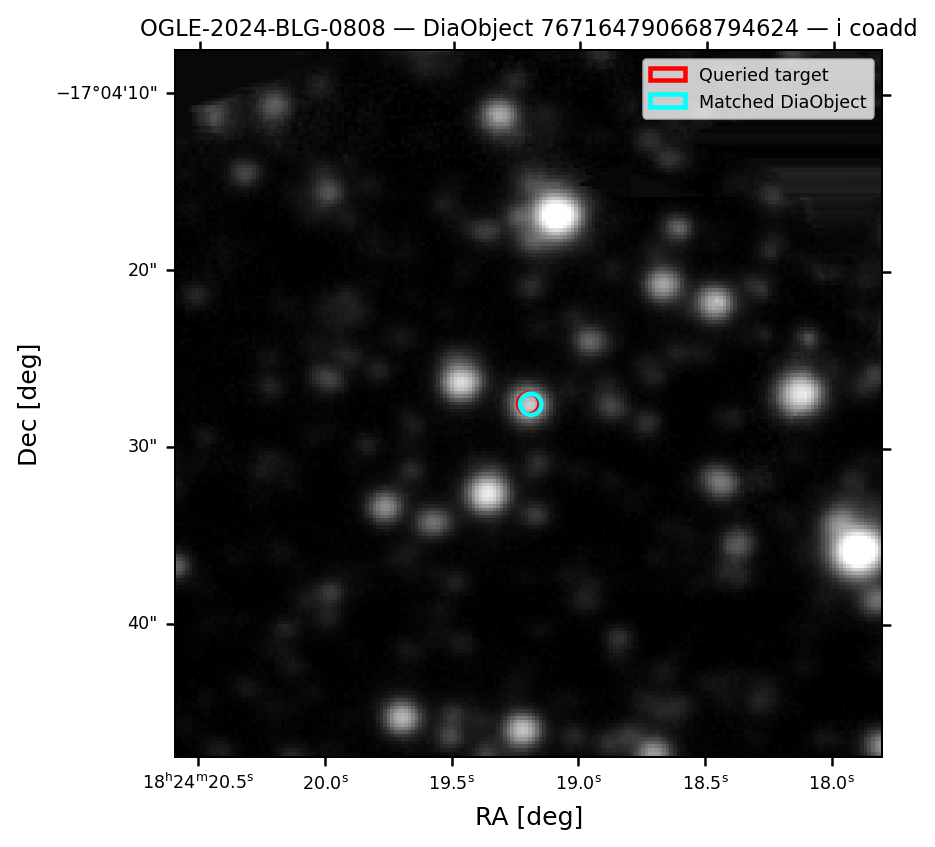

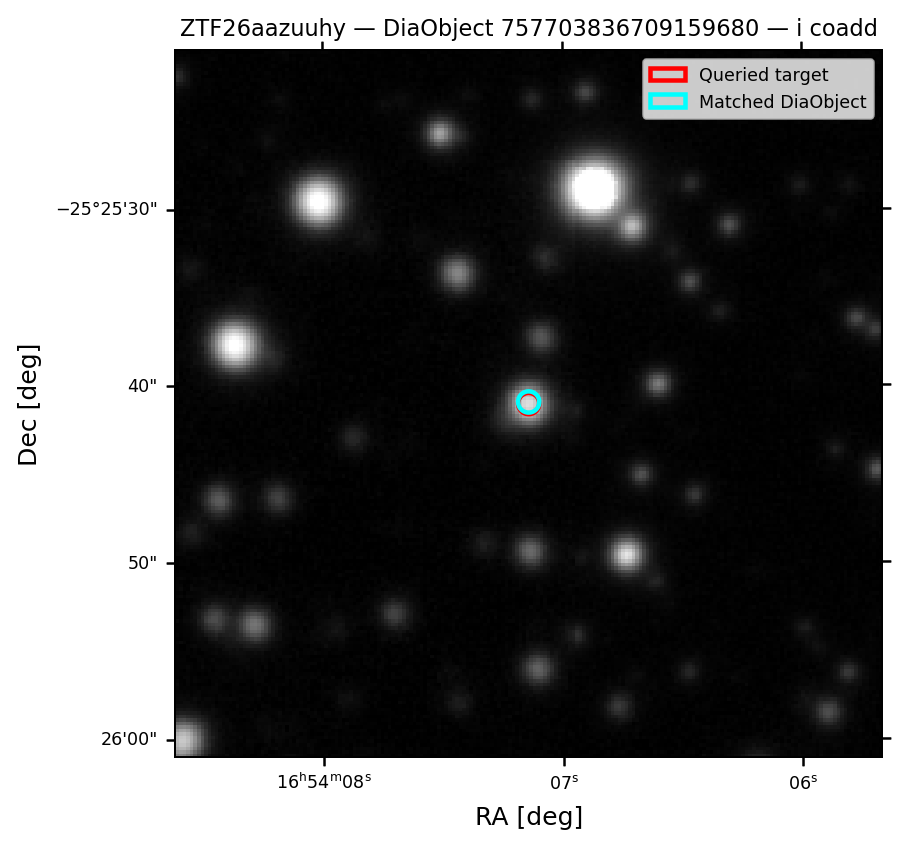

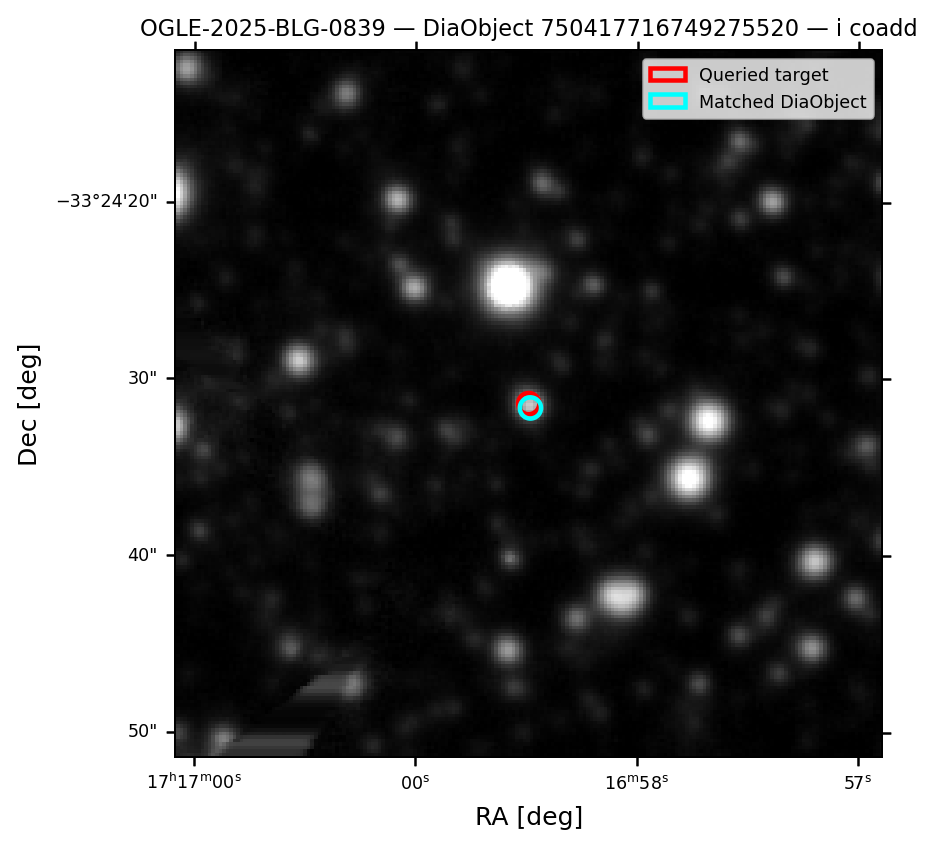

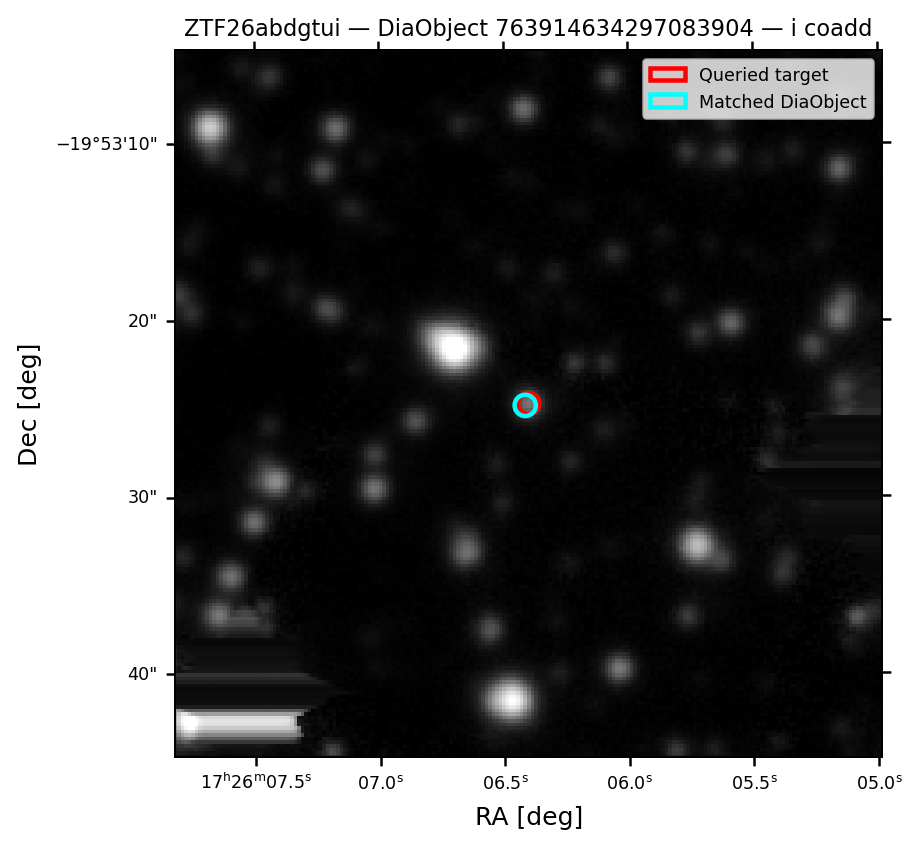

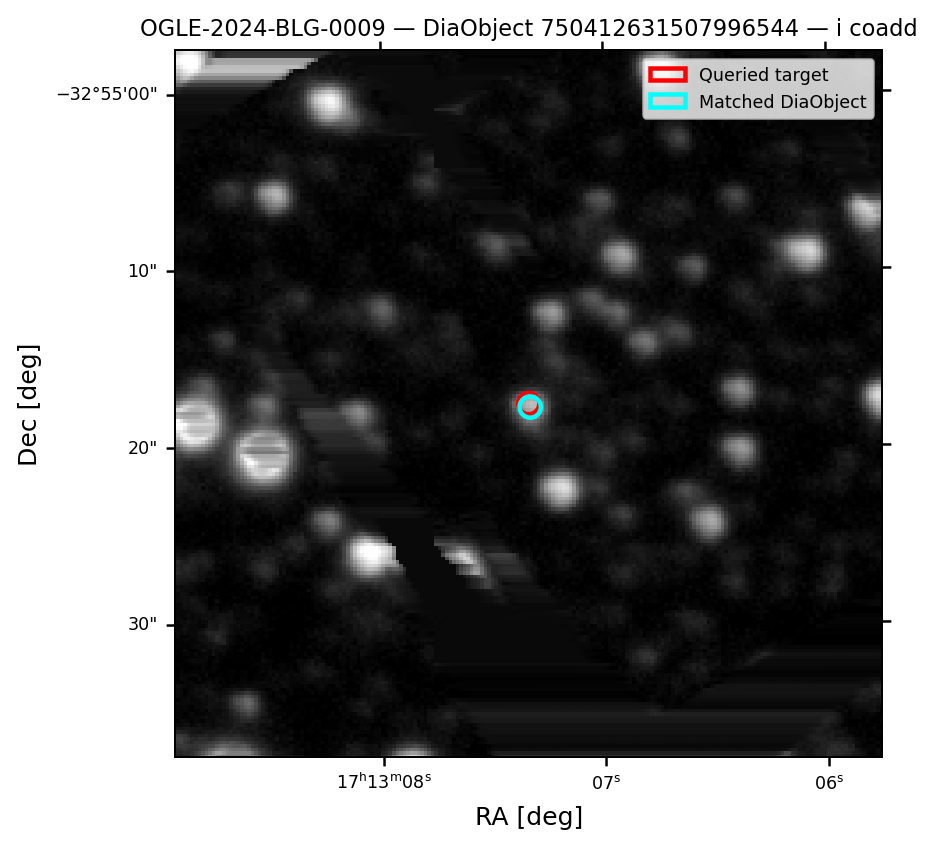

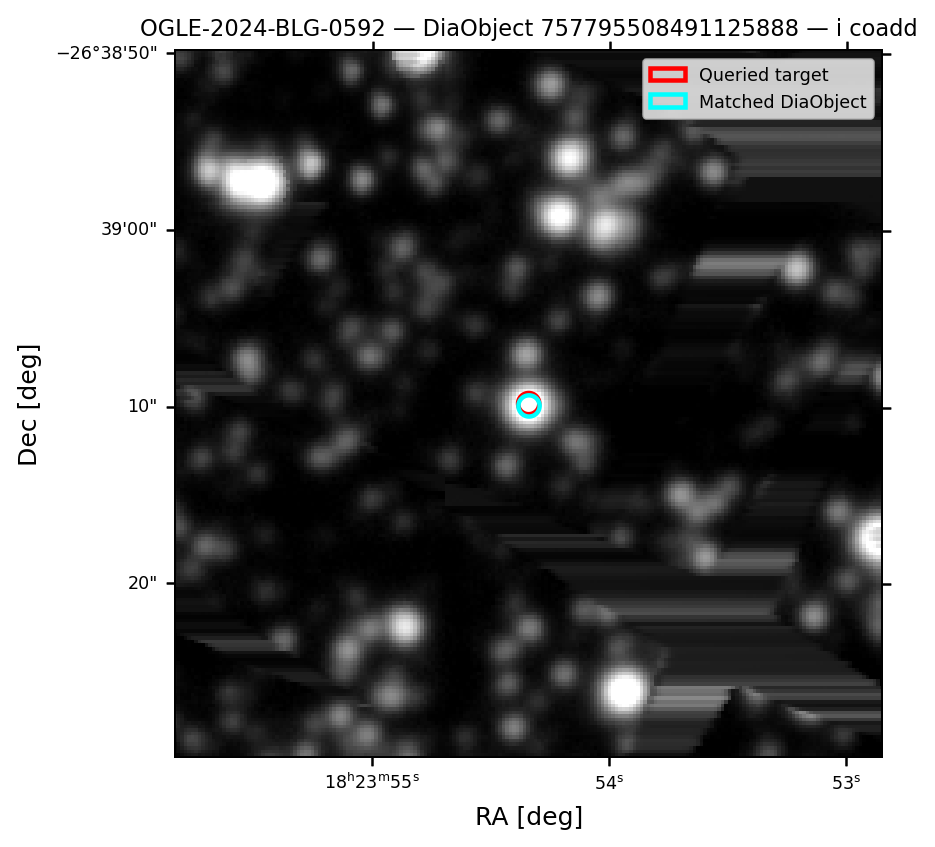

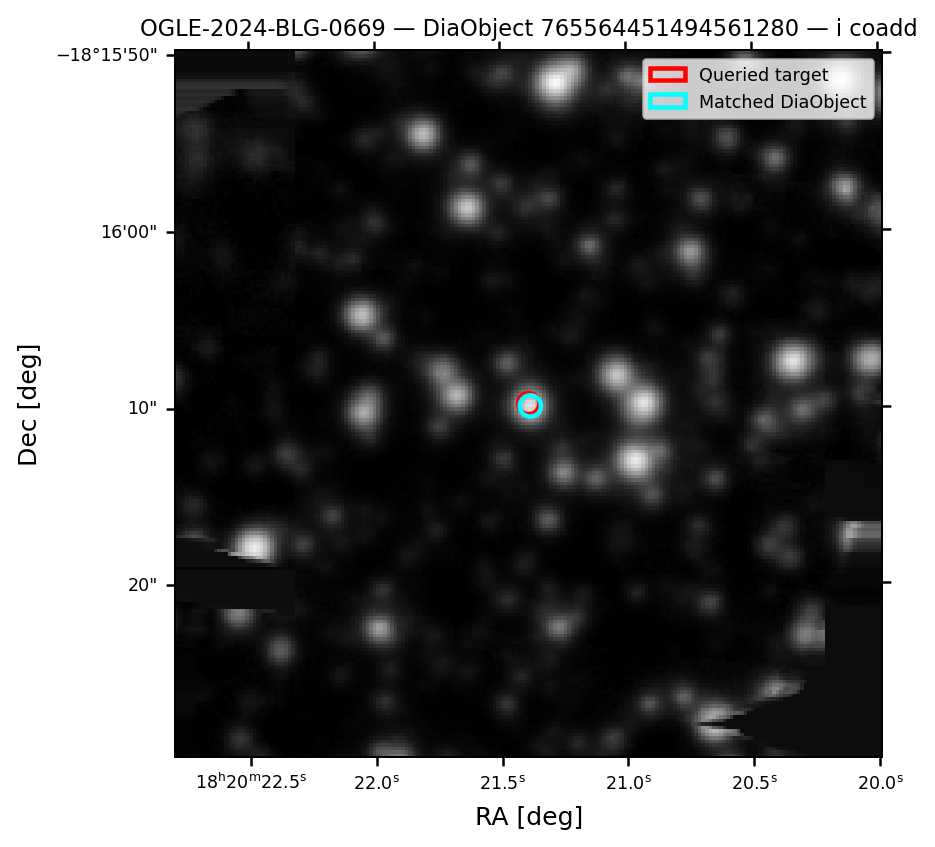

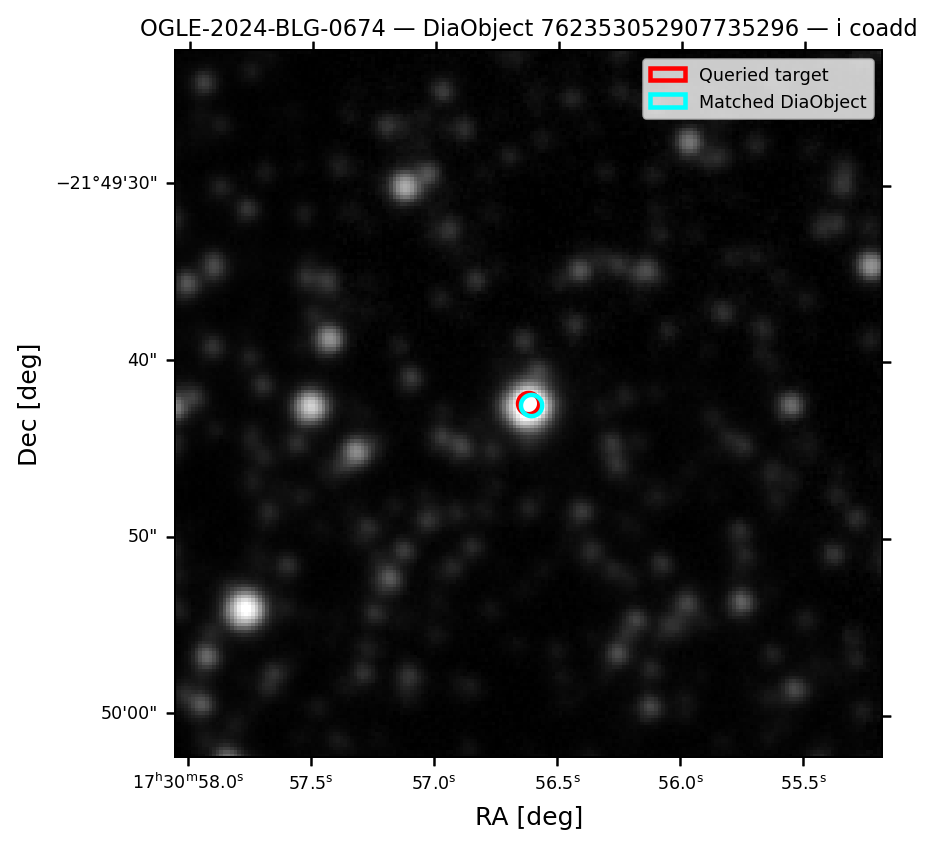

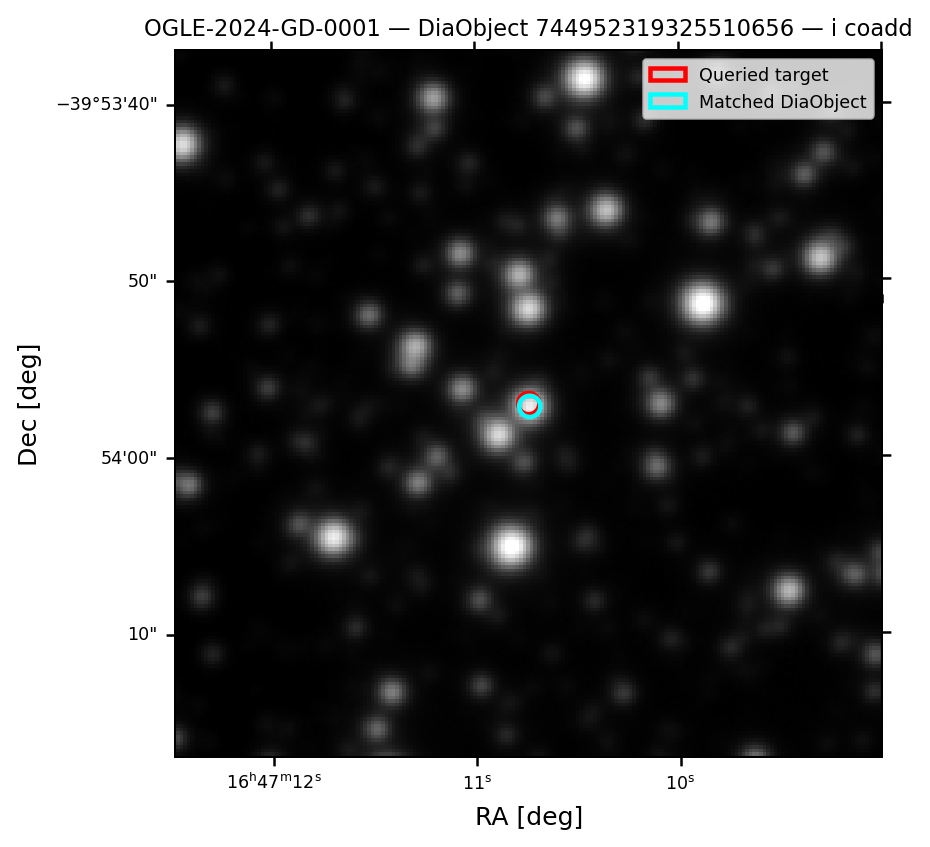

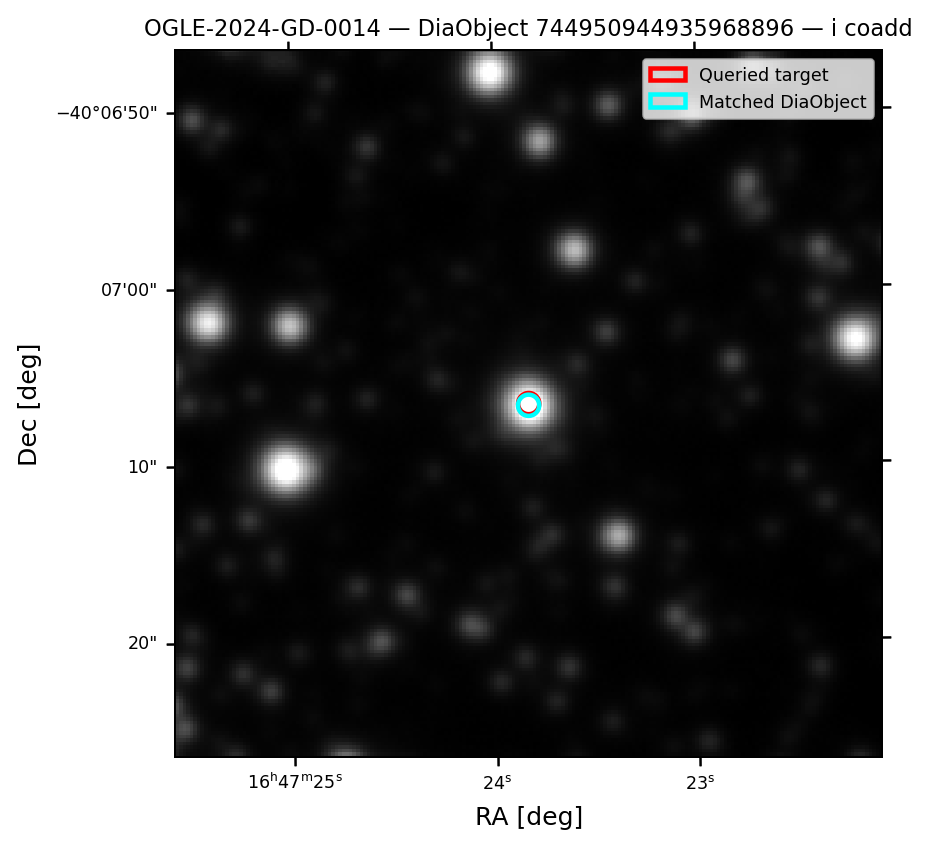

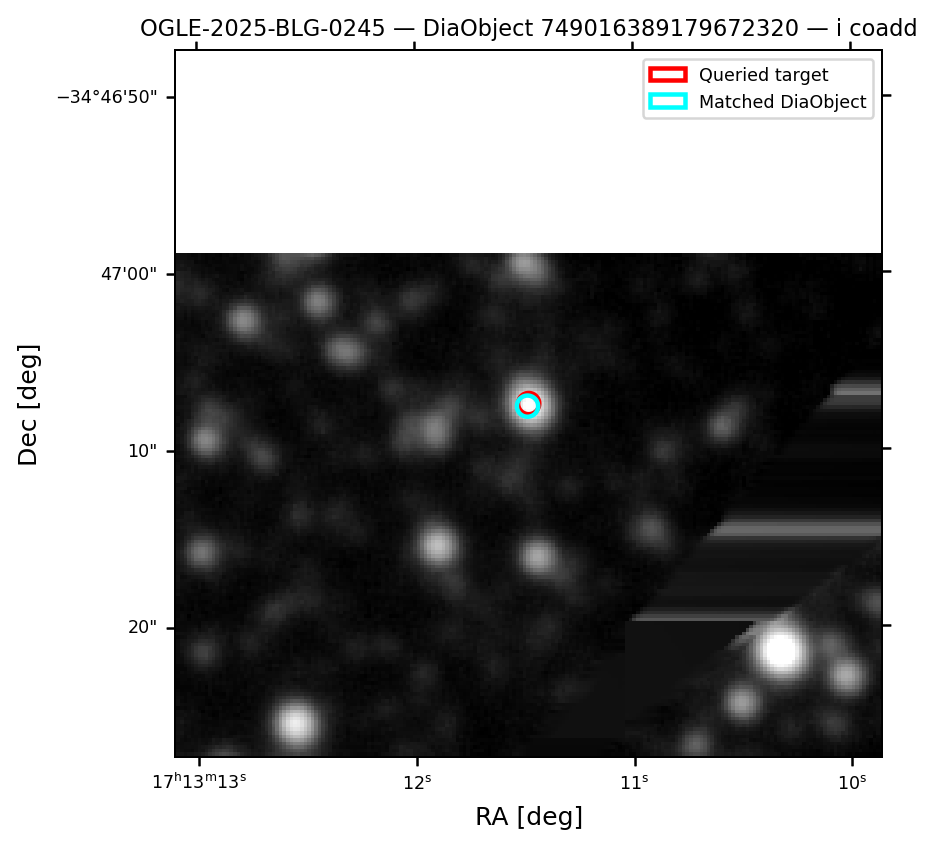

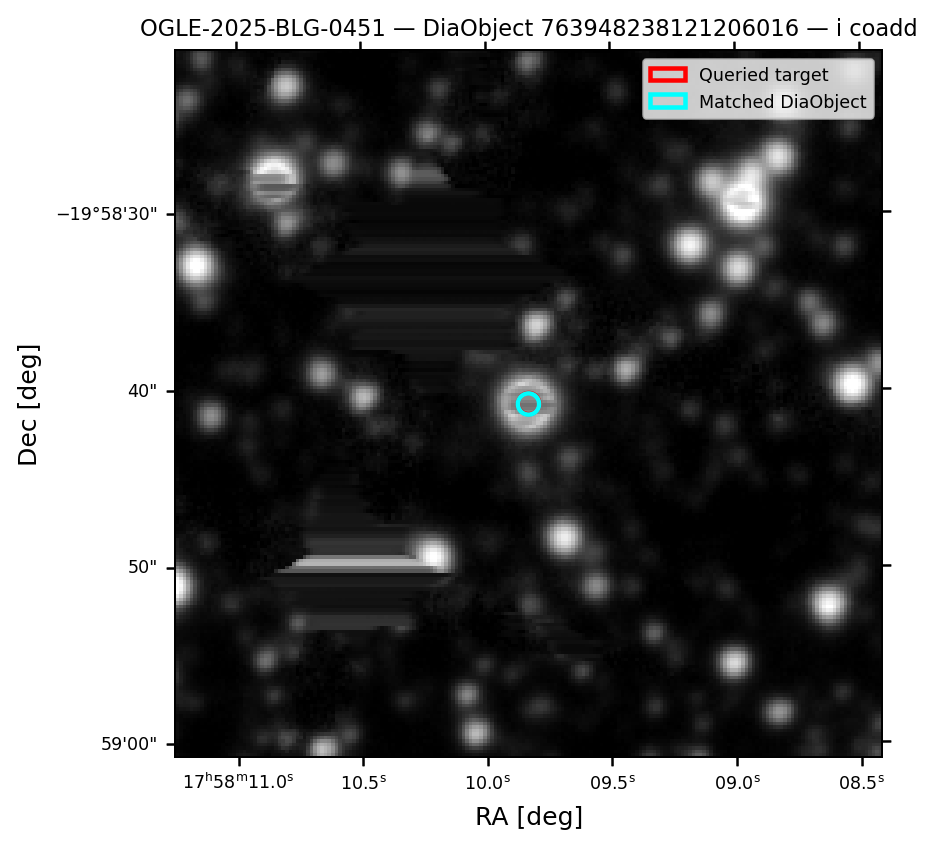

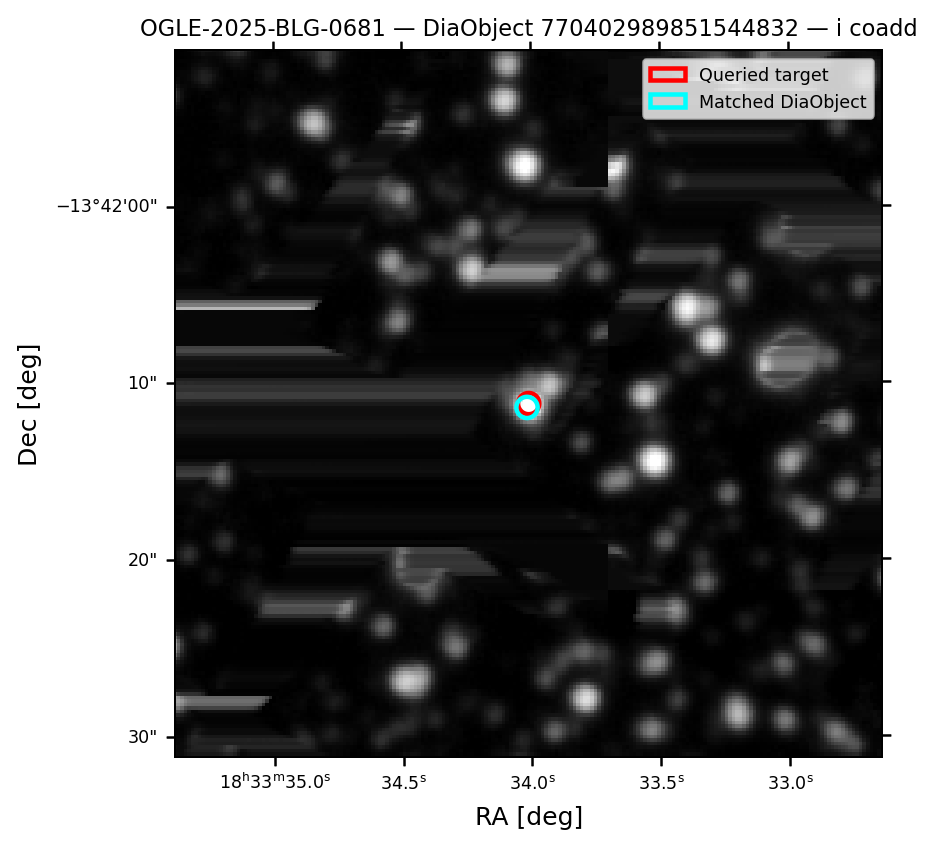

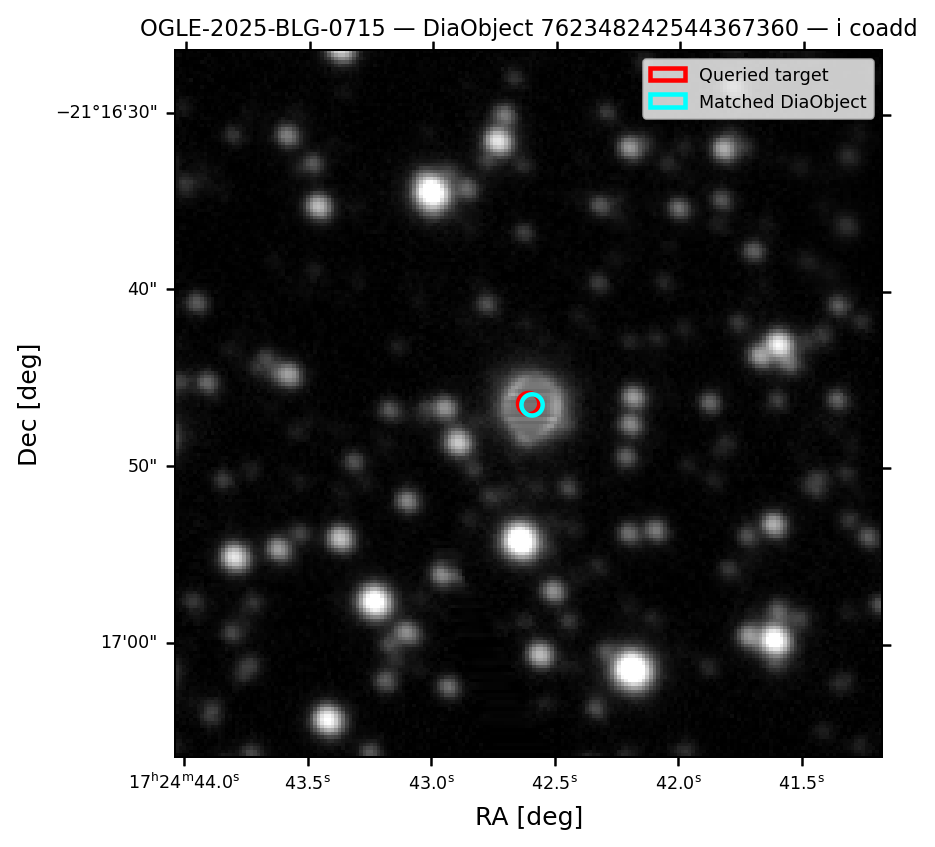

,Target,match_status,cutout_path
0,OGLE-2024-BLG-0808,accepted,/home/karennowo/target_selection/outputs/2026-...
1,ZTF26aazuuhy,accepted,/home/karennowo/target_selection/outputs/2026-...
2,OGLE-2025-BLG-0839,accepted,/home/karennowo/target_selection/outputs/2026-...
3,ZTF26abdgtui,accepted,/home/karennowo/target_selection/outputs/2026-...
4,OGLE-2024-BLG-0009,accepted,/home/karennowo/target_selection/outputs/2026-...
5,OGLE-2024-BLG-0592,accepted,/home/karennowo/target_selection/outputs/2026-...
6,OGLE-2024-BLG-0669,accepted,/home/karennowo/target_selection/outputs/2026-...
7,OGLE-2024-BLG-0674,accepted,/home/karennowo/target_selection/outputs/2026-...
8,OGLE-2024-GD-0001,accepted,/home/karennowo/target_selection/outputs/2026-...
9,OGLE-2024-GD-0014,accepted,/home/karennowo/target_selection/outputs/2026-...


,Target,match_status,match_sep_arcsec,candidate_count,lightcurve_eligible
0,OGLE-2024-BLG-0808,accepted,0.123341,1,True
1,OGLE-2026-GD-0001,no_match,NaN,0,False
2,OGLE-2025-BLG-0271,no_match,NaN,0,False
3,OGLE-2025-BLG-0242,no_match,NaN,0,False
4,ZTF26aazuuhy,accepted,0.090488,1,True
5,OGLE-2025-BLG-0839,accepted,0.267006,1,True
6,OGLE-2026-BLG-0128,no_match,NaN,0,False
7,OGLE-2025-BLG-1435,no_match,NaN,0,False
8,ZTF26abdgtui,accepted,0.221386,1,True
9,OGLE-2026-DG-0014,no_match,NaN,0,False


In [8]:
from IPython.display import Image, display

target_lookup = targets.set_index("Target", drop=False)
cutout_records = []
for match in matches.dropna(subset=["diaObjectId", "dia_ra_deg", "dia_dec_deg"]).itertuples(index=False):
    target = target_lookup.loc[match.Target]
    output_path = OUTPUT_DIRECTORY / "match_cutouts" / f"{match.Target}_dia_match_{match.match_status}.png"
    for stale_path in output_path.parent.glob(f"{match.Target}_dia_match_*.png"):
        if stale_path != output_path:
            stale_path.unlink()
    saved = save_dia_match_cutout(
        butler=butler, data_release=release, target_name=match.Target,
        target_ra_deg=target.RA_deg, target_dec_deg=target.Dec_deg,
        dia_object_id=int(match.diaObjectId), dia_ra_deg=match.dia_ra_deg, dia_dec_deg=match.dia_dec_deg,
        output_path=output_path,
    )
    cutout_records.append({
        "Target": match.Target, "match_status": match.match_status,
        "cutout_path": str(saved) if saved else "",
    })
    if saved is not None:
        display(Image(filename=str(saved)))

cutout_summary = pd.DataFrame(cutout_records)
cutout_summary.to_csv(OUTPUT_DIRECTORY / "dia_match_cutouts.csv", index=False)
matches = matches.merge(
    cutout_summary.drop(columns="match_status", errors="ignore"), on="Target", how="left",
)
matches["lightcurve_eligible"] = matches["match_status"].eq("accepted")
matches.to_csv(OUTPUT_DIRECTORY / "dia_match_diagnostics.csv", index=False)
display(cutout_summary)
display(matches[["Target", "match_status", "match_sep_arcsec", "candidate_count", "lightcurve_eligible"]])


## 4. Retrieve the accepted DP2 forced-source light curves

The DP2 table contains one forced PSF measurement per visit/detector at the matched `DiaObject`. The notebook saves the raw normalized result so it can be inspected independently of the figure.

In [9]:
accepted_names = set(matches.loc[matches["lightcurve_eligible"], "Target"])
accepted_targets = targets.loc[targets["Target"].isin(accepted_names), ["Target", "RA_deg", "Dec_deg"]]
dp2_photometry = query_dia_forced_photometry(
    accepted_targets, tap_service=tap_service, data_release=release,
    match_radius_arcsec=MATCH_RADIUS_ARCSEC, max_workers=4, verbose=True,
)
dp2_photometry.to_csv(OUTPUT_DIRECTORY / "dp2_dia_forced_photometry.csv", index=False)
display(dp2_photometry.groupby(["Target", "band"], dropna=False).size().rename("points").reset_index())

,Target,band,points
0,OGLE-2024-BLG-0009,i,5
1,OGLE-2024-BLG-0009,r,4
2,OGLE-2024-BLG-0009,y,1
3,OGLE-2024-BLG-0592,u,3
4,OGLE-2024-BLG-0592,y,4
5,OGLE-2024-BLG-0669,g,3
6,OGLE-2024-BLG-0669,u,2
7,OGLE-2024-BLG-0669,y,5
8,OGLE-2024-BLG-0674,g,4
9,OGLE-2024-BLG-0674,i,6


## 5. Plot MOP + HSH + DP2

HSH is shown as photometric points when normalized HSH photometry has been imported into the target database. If the database only contains the image inventory, its epochs are shown as a light shaded coverage band.

In [ ]:
def mjd_to_datetime(values):
    return pd.to_datetime(pd.to_numeric(values, errors="coerce"), unit="D", origin="1858-11-17", errors="coerce")

def plot_combined_lightcurve(target):
    name = str(target.Target)
    figure, axis = plt.subplots(figsize=(11, 4.2), constrained_layout=True)
    mop_data = load_event_photometry(target._asdict(), mop=mop, cache_dir=RUN_DIRECTORY / "mop_photometry")
    for filter_name in select_lightcurve_filters(mop_data):
        data = prepare_lightcurve_data(mop_data, filter_name)
        axis.errorbar(data["Timestamp"], data["Magnitude"], yerr=data.get("Error"), fmt=".", ms=3, alpha=.8, label=f"MOP {filter_name}")

    hsh_points = registry.photometry(pd.DataFrame([{"Target": name}]), sources=("HSH",))
    if not hsh_points.empty:
        hsh_points = hsh_points.assign(Timestamp=mjd_to_datetime(hsh_points["mjd"]))
        axis.errorbar(hsh_points["Timestamp"], hsh_points["magnitude"], yerr=hsh_points["magnitude_error"], fmt="o", mfc="white", ms=3, label="HSH photometry")
    else:
        hsh_epochs = registry.observation_epochs(pd.DataFrame([{"Target": name}]), providers=("HSH",))
        for epoch in mjd_to_datetime(hsh_epochs.get("mjd", pd.Series(dtype=float))).dropna().unique():
            axis.axvline(epoch, color="#d97706", alpha=.10, lw=1, zorder=0)

    dp2_data = dp2_photometry.loc[(dp2_photometry["Target"] == name) & (dp2_photometry["measurement_status"] == "measured")].copy()
    dp2_data["Timestamp"] = mjd_to_datetime(dp2_data["expMidptMJD"])
    for band, data in dp2_data.groupby("band", sort=True):
        data = data.dropna(subset=["Timestamp", "magnitude"])
        axis.errorbar(data["Timestamp"], data["magnitude"], yerr=data["magnitude_err"], fmt="s", ms=2.4, alpha=.75, label=f"DP2 {band}")

    axis.invert_yaxis()
    axis.set(title=f"{name}: MOP + HSH + DP2 DIA forced photometry", xlabel="Date", ylabel="Magnitude")
    axis.grid(alpha=.25)
    axis.legend(fontsize=7, ncol=3, frameon=False)
    return figure

for target in targets.itertuples(index=False):
    if target.Target not in accepted_names:
        continue
    figure = plot_combined_lightcurve(target)
    path = OUTPUT_DIRECTORY / f"{target.Target}_mop_hsh_dp2.png"
    figure.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(figure)

print(f"Saved diagnostics, raw DP2 rows, and figures in: {OUTPUT_DIRECTORY.resolve()}")